# 03 · Diagnóstico de deriva (distribution shift) para el split — Sara

**Corre en DATABRICKS** (usa Spark sobre Bronze y Silver). Objetivo: justificar
empíricamente el split train/test (Opción C), la cuarentena 15–17 nov y el manejo de
Black Friday, mirando cómo cambia la distribución de los datos en **ventanas de 15 días**.

**Plan:**
1. **Bronze** (crudo): volumen, mezcla de `event_type` y deriva de precio por ventana →
   confirma que la deriva está en los datos crudos, no es un artefacto de limpieza.
2. **Silver** (limpio): conversión a nivel **sesión** por ventana y por día (la etiqueta que
   modelas), composición de categoría y precio post-limpieza.
3. **PSI** (Population Stability Index): cuantifica la deriva vs la primera ventana.

> **Cuota:** toda la agregación se hace en Spark; solo bajamos a pandas las tablas
> resumen (pequeñas) para graficar. **Nunca** `toPandas()` sobre los eventos crudos.

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BRONZE = "/Volumes/workspace/default/e_commerce/bronze/clickstream"
SILVER = "/Volumes/workspace/default/e_commerce/silver/clickstream_clean"
WINDOW_DAYS = 15

# Helper: añade índice de ventana de 15 días a partir de una columna de fecha
def add_window(df, date_col, days=WINDOW_DAYS):
    min_d = df.agg(F.min(date_col)).first()[0]
    return df.withColumn("win", (F.datediff(F.col(date_col), F.lit(min_d)) / days).cast("int"))

# Helper: etiquetas de cada ventana (rango de fechas) para los ejes
def window_labels(df, date_col):
    wl = (add_window(df, date_col)
          .groupBy("win").agg(F.min(date_col).alias("ini"), F.max(date_col).alias("fin"))
          .orderBy("win").toPandas())
    wl["lab"] = wl["ini"].astype(str).str.slice(5) + "→" + wl["fin"].astype(str).str.slice(5)
    return wl

## BRONZE — composición cruda por ventana

### B1. Volumen y mezcla de `event_type` (view / cart / purchase)
La mezcla de eventos delata la **ventana corrupta**: si en una ventana hay `cart` pero la
`purchase` se desploma, la etiqueta está rota ahí.

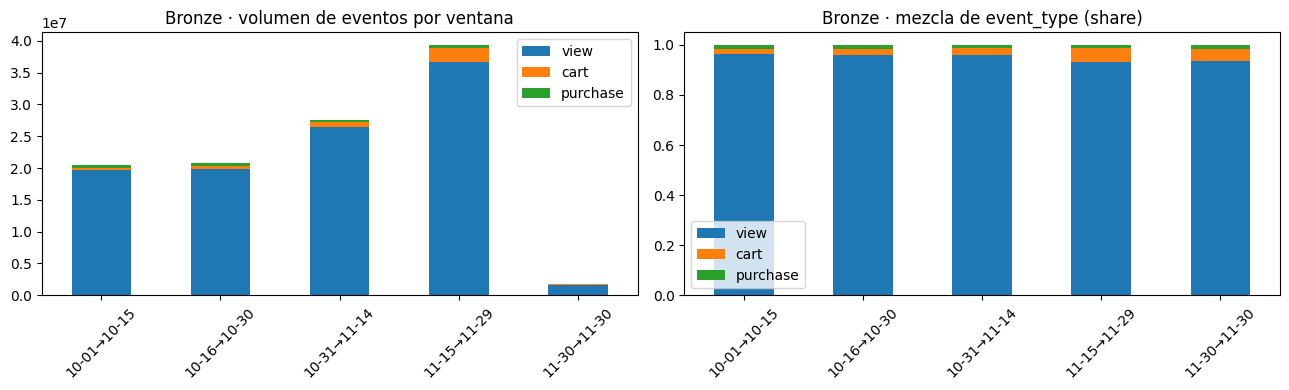

               view    cart  purchase
lab                                  
10-01→10-15  0.9630  0.0196    0.0174
10-16→10-30  0.9578  0.0246    0.0177
10-31→11-14  0.9597  0.0276    0.0128
11-15→11-29  0.9299  0.0559    0.0141
11-30→11-30  0.9374  0.0466    0.0161


In [0]:
bronze = add_window(spark.read.format("delta").load(BRONZE), "event_date")

mix = (bronze.groupBy("win").pivot("event_type", ["view", "cart", "purchase"]).count()
       .orderBy("win").toPandas().fillna(0).set_index("win"))
wl = window_labels(spark.read.format("delta").load(BRONZE), "event_date").set_index("win")
mix.index = wl.loc[mix.index, "lab"]

# Volumen total y shares
shares = mix.div(mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
mix.plot(kind="bar", stacked=True, ax=ax[0])
ax[0].set_title("Bronze · volumen de eventos por ventana"); ax[0].set_xlabel(""); ax[0].tick_params(axis='x', rotation=45)
shares.plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title("Bronze · mezcla de event_type (share)"); ax[1].set_xlabel(""); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print(shares.round(4))

### B2. Deriva de precio por ventana (percentiles)
Si lo que se ve/compra cambia de precio entre Oct y Nov (p.ej. descuentos de BF), es deriva
de la feature de precio que tu modelo va a usar.

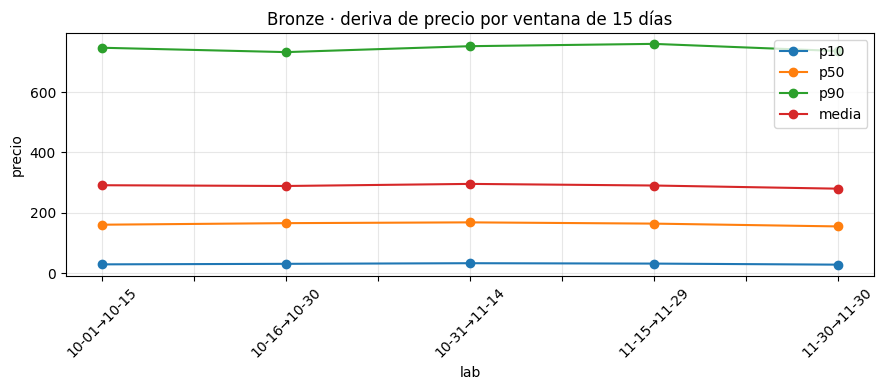

In [0]:
q = (bronze.groupBy("win")
     .agg(F.expr("percentile_approx(price, 0.10)").alias("p10"),
          F.expr("percentile_approx(price, 0.50)").alias("p50"),
          F.expr("percentile_approx(price, 0.90)").alias("p90"),
          F.avg("price").alias("media"))
     .orderBy("win").toPandas().set_index("win"))
q.index = wl.loc[q.index, "lab"]

q[["p10","p50","p90","media"]].plot(marker="o", figsize=(9,4))
plt.title("Bronze · deriva de precio por ventana de 15 días"); plt.ylabel("precio"); plt.xticks(rotation=45)
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## SILVER — la deriva que de verdad importa para el split

### S1. Tasa de conversión por SESIÓN — diaria (expone corrupción y BF)
Esta es la **distribución de tu etiqueta** en el tiempo. La línea diaria revela lo que las
ventanas de 15 días esconden: el desplome 15–17 nov (etiqueta corrupta) y el pico de Black Friday.

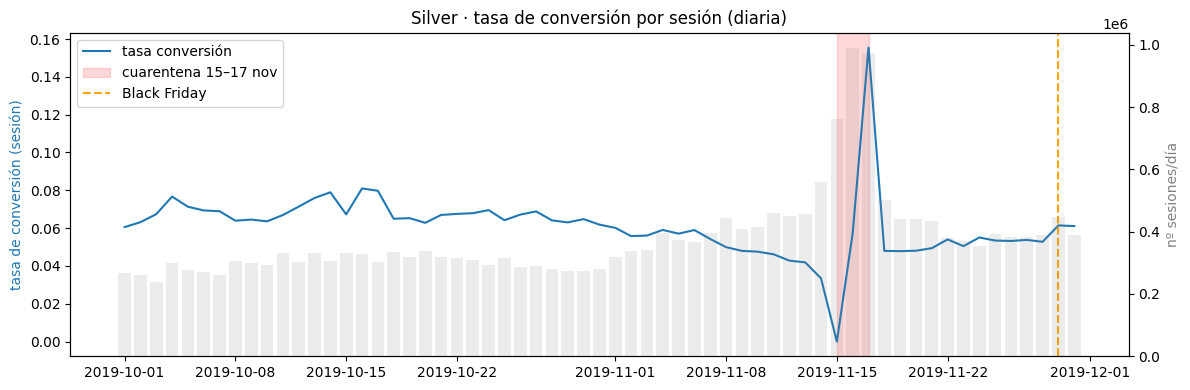

In [0]:
silver = spark.read.format("delta").load(SILVER)

# Conversión a nivel sesión: ¿la sesión tuvo purchase? + fecha de inicio de la sesión
sess = (silver.groupBy("user_session")
        .agg(F.max(F.when(F.col("event_type") == "purchase", 1).otherwise(0)).alias("conv"),
             F.min("date").alias("sdate")))

daily = (sess.groupBy("sdate").agg(F.avg("conv").alias("tasa"), F.count("*").alias("n_sesiones"))
         .orderBy("sdate").toPandas())
daily["sdate"] = pd.to_datetime(daily["sdate"])

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(daily["sdate"], daily["tasa"], color="tab:blue", label="tasa conversión")
ax1.set_ylabel("tasa de conversión (sesión)", color="tab:blue")
# Marcas: ventana corrupta 15-17 nov y Black Friday 29 nov
ax1.axvspan(pd.Timestamp("2019-11-15"), pd.Timestamp("2019-11-17"), color="red", alpha=.15, label="cuarentena 15–17 nov")
ax1.axvline(pd.Timestamp("2019-11-29"), color="orange", ls="--", label="Black Friday")
ax2 = ax1.twinx(); ax2.bar(daily["sdate"], daily["n_sesiones"], alpha=.15, color="grey")
ax2.set_ylabel("nº sesiones/día", color="grey")
ax1.set_title("Silver · tasa de conversión por sesión (diaria)"); ax1.legend(loc="upper left")
plt.tight_layout(); plt.show()

### S2. Conversión por ventana de 15 días (la vista pedida)
Misma señal agregada a 15 días: ¿el régimen Oct ≈ régimen Nov (fuera de la corrupción)?
Si sí → Opción C (train Oct+Nov≤23 / test Nov 24–30) queda bien justificada.

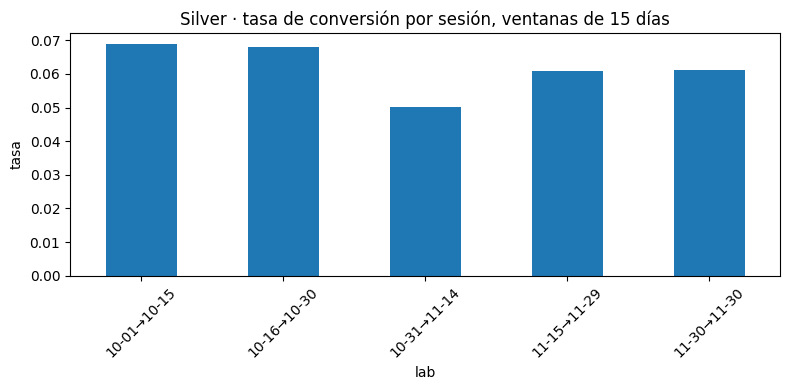

               tasa  n_sesiones
lab                            
10-01→10-15  0.0688     4380679
10-16→10-30  0.0679     4578697
10-31→11-14  0.0503     6003825
11-15→11-29  0.0608     7642462
11-30→11-30  0.0611      390013


In [0]:
sess_w = add_window(sess, "sdate")
conv_w = (sess_w.groupBy("win").agg(F.avg("conv").alias("tasa"), F.count("*").alias("n_sesiones"))
          .orderBy("win").toPandas().set_index("win"))
wl_s = window_labels(silver.withColumnRenamed("date", "date"), "date")  # etiquetas desde Silver
# etiquetas por ventana de sesión:
wl_sess = window_labels(sess.withColumnRenamed("sdate","sdate"), "sdate").set_index("win")
conv_w.index = wl_sess.loc[conv_w.index, "lab"]

ax = conv_w["tasa"].plot(kind="bar", figsize=(8,4), color="tab:blue")
ax.set_title("Silver · tasa de conversión por sesión, ventanas de 15 días"); ax.set_ylabel("tasa")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(conv_w.round(4))

### S3. Deriva de composición de categoría (`macro_category`)
Cambios en *qué* se navega (p.ej. más electrónica cerca de BF) también son deriva.

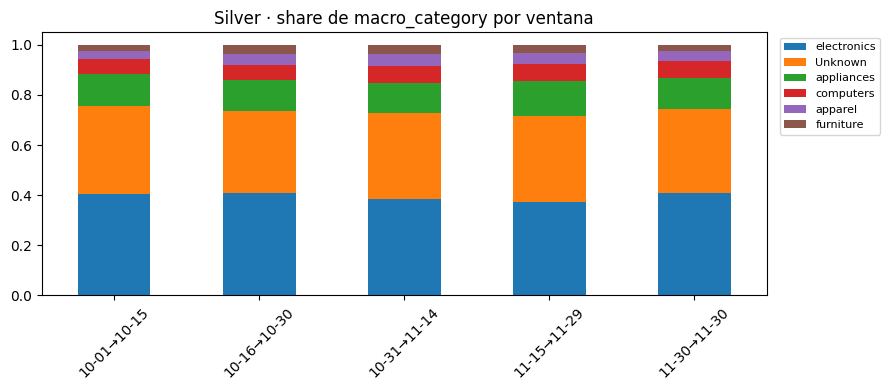

In [0]:
top = [r["macro_category"] for r in silver.groupBy("macro_category").count()
       .orderBy(F.desc("count")).limit(6).collect()]
silver_w = add_window(silver, "date")
cat = (silver_w.filter(F.col("macro_category").isin(top))
       .groupBy("win").pivot("macro_category", top).count()
       .orderBy("win").toPandas().fillna(0).set_index("win"))
cat.index = wl_sess.loc[cat.index, "lab"] if set(cat.index).issubset(wl_sess.index) else cat.index
cat_share = cat.div(cat.sum(axis=1), axis=0)

cat_share.plot(kind="bar", stacked=True, figsize=(9,4))
plt.title("Silver · share de macro_category por ventana"); plt.xlabel(""); plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.01,1), fontsize=8); plt.tight_layout(); plt.show()

## PSI — cuantificar la deriva

El **Population Stability Index** mide cuánto cambió una distribución vs una referencia
(la primera ventana). Regla habitual: **< 0.10** estable · **0.10–0.25** moderado ·
**> 0.25** deriva significativa. Lo calculamos sobre `price` (Silver).

In [0]:
def psi(ref, cur, bins=10):
    # bordes por cuantiles de la referencia
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    r = np.histogram(ref, edges)[0] / len(ref)
    c = np.histogram(cur, edges)[0] / len(cur)
    r, c = np.clip(r, 1e-6, None), np.clip(c, 1e-6, None)
    return float(np.sum((c - r) * np.log(c / r)))

# Muestra acotada por ventana (PSI no necesita millones de filas): ~50k precios/ventana
mp = (add_window(silver, "date").select("win", "price")
      .sampleBy("win", fractions={w: 1.0 for w in range(0, 6)}, seed=42))  # ajusta si quieres muestrear
prices = {w: g["price"].values for w, g in mp.toPandas().groupby("win")}

ref_win = min(prices)
print(f"Referencia = ventana {ref_win}\n")
for w in sorted(prices):
    val = psi(prices[ref_win], prices[w])
    flag = "estable" if val < 0.10 else ("moderado" if val < 0.25 else "⚠️ SIGNIFICATIVO")
    print(f"PSI(precio) ventana {ref_win}→{w}: {val:.4f}  [{flag}]")

Referencia = ventana 0

PSI(precio) ventana 0→0: 0.0000  [estable]
PSI(precio) ventana 0→1: 0.0022  [estable]
PSI(precio) ventana 0→2: 0.0045  [estable]
PSI(precio) ventana 0→3: 0.0058  [estable]
PSI(precio) ventana 0→4: 0.0027  [estable]


## Cómo leer esto para el split

- **Régimen Oct vs Nov estable** (tasa de conversión por ventana parecida, fuera de la
  corrupción; PSI de precio < 0.25) → **Opción C** queda bien justificada: entrenas con Oct+Nov
  hasta el 23 y evalúas Nov 24–30 *out-of-time* sin mezclar regímenes.
- **Desplome 15–17 nov** en la línea diaria (conversión → ~0 con `cart` presente) → confirma la
  **cuarentena**: excluir esos días de train y test (`label_window_corrupt == 1`).
- **Pico de Black Friday (29)** → confirma reportar el test **con y sin** BF (y el 30).
- Si vieras **deriva fuerte Oct→Nov** (PSI alto, tasas muy distintas) → reforzaría preferir un
  test dentro del régimen de Nov (lo que C ya hace) y documentar el shift en la defensa.

> Lleva la línea diaria (S1) y la tabla de PSI al empalme con Yeison: son la evidencia objetiva
> para cerrar el corte exacto del split y si van Híbrida (C + A como sensibilidad).